<a href="https://colab.research.google.com/github/Luyanda2006/GovernmentElections/blob/main/22402069DumaL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Duma L
22402069

DATASET LINKS

ETH(3) https://results.elections.org.za/home/Downloads/ME-Results election year 2021, downloadable detailed results, KZN province, eThekwini municipality, all ballots

ETH(1) https://results.elections.org.za/home/Downloads/ME-Results election year 2016, downloadable detailed results, KZN province, eThekwini municipality, all ballots

ETH(2) https://results.elections.org.za/home/Downloads/ME-Results election year 2011, downloadable detailed results, KZN province, eThekwini municipality, all ballots

##1. Problem definition

Title

Predictive Modeling SA Municipal Elections

Historical South African municipal election datasets exist only as discrete,This sparse temporal baseline prevents standard algorithms from tracking political shifts

In this note book I made use of three datasets, showing results of three different years to improve my time series and prepare my data efficiently for forecasting

##2. Data Collection

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)

In [85]:
df_2016 = pd.read_csv('ETH (1).csv', encoding='latin1')
df_2011 = pd.read_csv('ETH (2).csv', encoding='latin1')
df_2021 = pd.read_csv('ETH (3).csv', encoding='latin1')

In [86]:
df_2016['Election_Year'] = 2016
df_2011['Election_Year'] = 2011
df_2021['Election_Year'] = 2021

In [87]:
#stacking and merging the 3 datasets
ethekwini_ts = pd.concat([df_2016, df_2011, df_2021], ignore_index=True)

print("Data successfully loaded and merged!")

Data successfully loaded and merged!


##3. Data Understanding

In [88]:
ethekwini_ts.head()

,ï»¿Province,Municipality,Ward,VotingDistrict,VotingStationName,RegisteredVoters,BallotType,SpoiltVotes,PartyName,TotalValidVotes,...,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179.0,NOMFIHLELA PRIMARY SCHOOL,1607.0,PR,72.0,ACADEMIC CONGRESS UNION,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179.0,NOMFIHLELA PRIMARY SCHOOL,1607.0,PR,72.0,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179.0,NOMFIHLELA PRIMARY SCHOOL,1607.0,PR,72.0,AFRICAN INDEPENDENT CONGRESS,19.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179.0,NOMFIHLELA PRIMARY SCHOOL,1607.0,PR,72.0,AFRICAN MANTUNGWA COMMUNITY,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179.0,NOMFIHLELA PRIMARY SCHOOL,1607.0,PR,72.0,AFRICAN NATIONAL CONGRESS,1157.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [89]:
ethekwini_ts.tail()

,ï»¿Province,Municipality,Ward,VotingDistrict,VotingStationName,RegisteredVoters,BallotType,SpoiltVotes,PartyName,TotalValidVotes,...,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10
167129,KwaZulu-Natal,ETH - eThekwini,Ward 59500111,43583698.0,MATHOLE COMMUNITY HALL,1962.0,Ward,29.0,PEOPLE'S FREEDOM PARTY,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
167130,KwaZulu-Natal,ETH - eThekwini,Ward 59500111,43583698.0,MATHOLE COMMUNITY HALL,1962.0,Ward,29.0,THE ORGANIC HUMANITY MOVEMENT,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
167131,KwaZulu-Natal,ETH - eThekwini,Ward 59500111,43583698.0,MATHOLE COMMUNITY HALL,1962.0,Ward,29.0,TRULY ALLIANCE,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
167132,KwaZulu-Natal,ETH - eThekwini,Ward 59500111,43583698.0,MATHOLE COMMUNITY HALL,1962.0,Ward,29.0,UNITED INDEPENDENT MOVEMENT,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
167133,KwaZulu-Natal,ETH - eThekwini,Ward 59500111,43583698.0,MATHOLE COMMUNITY HALL,1962.0,Ward,29.0,VRYHEIDSFRONT PLUS,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [90]:
ethekwini_ts.shape

(167134, 23)

In [91]:
ethekwini_ts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167134 entries, 0 to 167133
Data columns (total 23 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   ï»¿Province        117446 non-null  object 
 1   Municipality       117446 non-null  object 
 2   Ward               117446 non-null  object 
 3   VotingDistrict     117446 non-null  float64
 4   VotingStationName  117446 non-null  object 
 5   RegisteredVoters   117446 non-null  float64
 6   BallotType         117446 non-null  object 
 7   SpoiltVotes        117446 non-null  float64
 8   PartyName          117446 non-null  object 
 9   TotalValidVotes    117446 non-null  float64
 10  DateGenerated      117446 non-null  object 
 11  Election_Year      167134 non-null  int64  
 12  ÿþP                0 non-null       float64
 13  Unnamed: 1         0 non-null       float64
 14  Unnamed: 2         0 non-null       float64
 15  Unnamed: 3         0 non-null       float64
 16  Un

In [92]:
print(ethekwini_ts.columns.tolist())

['ï»¿Province', 'Municipality', 'Ward', 'VotingDistrict', 'VotingStationName', 'RegisteredVoters', 'BallotType', 'SpoiltVotes', 'PartyName', 'TotalValidVotes', 'DateGenerated', 'Election_Year', 'ÿþP', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10']


In [93]:
ethekwini_ts.describe()

,VotingDistrict,RegisteredVoters,SpoiltVotes,TotalValidVotes,Election_Year,ÿþP,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10
count,1.174460e+05,117446.000000,117446.000000,117446.000000,167134.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,4.342083e+07,2195.598139,22.704511,32.153977,2016.809291,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,1.030853e+05,1199.896212,35.345150,160.627216,4.272743,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,4.335002e+07,101.000000,0.000000,0.000000,2011.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,4.336174e+07,1367.000000,6.000000,0.000000,2011.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,4.337166e+07,2076.000000,14.000000,0.000000,2016.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,4.340057e+07,2826.000000,28.000000,3.000000,2021.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,4.407007e+07,8099.000000,993.000000,4175.000000,2021.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


##4. Data Preparation

In [94]:
missing_values = ethekwini_ts.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
ï»¿Province           49688
Municipality          49688
Ward                  49688
VotingDistrict        49688
VotingStationName     49688
RegisteredVoters      49688
BallotType            49688
SpoiltVotes           49688
PartyName             49688
TotalValidVotes       49688
DateGenerated         49688
Election_Year             0
ÿþP                  167134
Unnamed: 1           167134
Unnamed: 2           167134
Unnamed: 3           167134
Unnamed: 4           167134
Unnamed: 5           167134
Unnamed: 6           167134
Unnamed: 7           167134
Unnamed: 8           167134
Unnamed: 9           167134
Unnamed: 10          167134
dtype: int64


In [95]:
duplicate_count = ethekwini_ts.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 49687


In [96]:
ethekwini_ts = ethekwini_ts.drop_duplicates()

print("Duplicates removed.")
print("New dataset shape:", ethekwini_ts.shape)

Duplicates removed.
New dataset shape: (117447, 23)


In [97]:
ethekwini_ts.reset_index(drop=True, inplace=True)

ethekwini_ts.head()

,ï»¿Province,Municipality,Ward,VotingDistrict,VotingStationName,RegisteredVoters,BallotType,SpoiltVotes,PartyName,TotalValidVotes,...,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179.0,NOMFIHLELA PRIMARY SCHOOL,1607.0,PR,72.0,ACADEMIC CONGRESS UNION,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179.0,NOMFIHLELA PRIMARY SCHOOL,1607.0,PR,72.0,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179.0,NOMFIHLELA PRIMARY SCHOOL,1607.0,PR,72.0,AFRICAN INDEPENDENT CONGRESS,19.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179.0,NOMFIHLELA PRIMARY SCHOOL,1607.0,PR,72.0,AFRICAN MANTUNGWA COMMUNITY,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179.0,NOMFIHLELA PRIMARY SCHOOL,1607.0,PR,72.0,AFRICAN NATIONAL CONGRESS,1157.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [98]:
print(ethekwini_ts.dtypes)

ï»¿Province           object
Municipality          object
Ward                  object
VotingDistrict       float64
VotingStationName     object
RegisteredVoters     float64
BallotType            object
SpoiltVotes          float64
PartyName             object
TotalValidVotes      float64
DateGenerated         object
Election_Year          int64
ÿþP                  float64
Unnamed: 1           float64
Unnamed: 2           float64
Unnamed: 3           float64
Unnamed: 4           float64
Unnamed: 5           float64
Unnamed: 6           float64
Unnamed: 7           float64
Unnamed: 8           float64
Unnamed: 9           float64
Unnamed: 10          float64
dtype: object


In [99]:
# Clean column names

ethekwini_ts.columns = (
    ethekwini_ts.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

print(ethekwini_ts.columns.tolist())

['ï»¿province', 'municipality', 'ward', 'votingdistrict', 'votingstationname', 'registeredvoters', 'ballottype', 'spoiltvotes', 'partyname', 'totalvalidvotes', 'dategenerated', 'election_year', 'ÿþp', 'unnamed:_1', 'unnamed:_2', 'unnamed:_3', 'unnamed:_4', 'unnamed:_5', 'unnamed:_6', 'unnamed:_7', 'unnamed:_8', 'unnamed:_9', 'unnamed:_10']


In [100]:
numeric_columns = ethekwini_ts.select_dtypes(
    include=np.number
).columns.tolist()

print("Numeric columns:")
print(numeric_columns)

Numeric columns:
['votingdistrict', 'registeredvoters', 'spoiltvotes', 'totalvalidvotes', 'election_year', 'ÿþp', 'unnamed:_1', 'unnamed:_2', 'unnamed:_3', 'unnamed:_4', 'unnamed:_5', 'unnamed:_6', 'unnamed:_7', 'unnamed:_8', 'unnamed:_9', 'unnamed:_10']


In [101]:
categorical_columns = ethekwini_ts.select_dtypes(
    include='object'
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['ï»¿province', 'municipality', 'ward', 'votingstationname', 'ballottype', 'partyname', 'dategenerated']


In [102]:
possible_numeric_columns = [
    col for col in ethekwini_ts.columns
    if any(word in col for word in [
        'vote',
        'votes',
        'turnout',
        'percentage',
        'percent',
        'total',
        'count',
        'registered'
    ])
]

print("Possible numerical columns:")
print(possible_numeric_columns)

Possible numerical columns:
['registeredvoters', 'spoiltvotes', 'totalvalidvotes']


In [103]:
possible_numeric_columns = [
    col for col in ethekwini_ts.columns
    if any(word in col for word in [
        'vote', 'votes', 'turnout', 'percentage',
        'percent', 'total', 'count', 'registered'
    ])
]

for col in possible_numeric_columns:
    ethekwini_ts.loc[:, col] = pd.to_numeric(
        ethekwini_ts[col], errors='coerce'
    )

print(ethekwini_ts.dtypes)

ï»¿province           object
municipality          object
ward                  object
votingdistrict       float64
votingstationname     object
registeredvoters     float64
ballottype            object
spoiltvotes          float64
partyname             object
totalvalidvotes      float64
dategenerated         object
election_year          int64
ÿþp                  float64
unnamed:_1           float64
unnamed:_2           float64
unnamed:_3           float64
unnamed:_4           float64
unnamed:_5           float64
unnamed:_6           float64
unnamed:_7           float64
unnamed:_8           float64
unnamed:_9           float64
unnamed:_10          float64
dtype: object


In [104]:
print("Total missing values:",
      ethekwini_ts.isnull().sum().sum())

Total missing values: 1291928


In [105]:
for col in numeric_columns:
    negative_count = (ethekwini_ts[col] < 0).sum()

    if negative_count > 0:
        print(col, "contains", negative_count, "negative values")
    else: print(col, "does not contain negative values")

votingdistrict does not contain negative values
registeredvoters does not contain negative values
spoiltvotes does not contain negative values
totalvalidvotes does not contain negative values
election_year does not contain negative values
ÿþp does not contain negative values
unnamed:_1 does not contain negative values
unnamed:_2 does not contain negative values
unnamed:_3 does not contain negative values
unnamed:_4 does not contain negative values
unnamed:_5 does not contain negative values
unnamed:_6 does not contain negative values
unnamed:_7 does not contain negative values
unnamed:_8 does not contain negative values
unnamed:_9 does not contain negative values
unnamed:_10 does not contain negative values


In [106]:
#outliers
for col in numeric_columns:

    Q1 = ethekwini_ts[col].quantile(0.25)
    Q3 = ethekwini_ts[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = ethekwini_ts[
        (ethekwini_ts[col] < lower_bound) |
        (ethekwini_ts[col] > upper_bound)
    ]

    print(col, ":", len(outliers), "possible outliers")

votingdistrict : 24491 possible outliers
registeredvoters : 3096 possible outliers
spoiltvotes : 7441 possible outliers
totalvalidvotes : 21027 possible outliers
election_year : 0 possible outliers
ÿþp : 0 possible outliers
unnamed:_1 : 0 possible outliers
unnamed:_2 : 0 possible outliers
unnamed:_3 : 0 possible outliers
unnamed:_4 : 0 possible outliers
unnamed:_5 : 0 possible outliers
unnamed:_6 : 0 possible outliers
unnamed:_7 : 0 possible outliers
unnamed:_8 : 0 possible outliers
unnamed:_9 : 0 possible outliers
unnamed:_10 : 0 possible outliers


In [107]:
# 1. Drop all corrupted and empty unneeded columns
columns_to_drop = ['ÿþp'] + [f'unnamed:_{i}' for i in range(1, 11)]
ethekwini_ts.drop(columns=columns_to_drop, errors='ignore', inplace=True)

# 2. Fix the broken corrupted province header name
ethekwini_ts.rename(columns={'ï»¿province': 'province'}, inplace=True)

# 3. Verify your clean structural columns
print("Remaining features for analysis:")
print(ethekwini_ts.columns.tolist())

Remaining features for analysis:
['province', 'municipality', 'ward', 'votingdistrict', 'votingstationname', 'registeredvoters', 'ballottype', 'spoiltvotes', 'partyname', 'totalvalidvotes', 'dategenerated', 'election_year']


In [108]:
print("Rows:", ethekwini_ts.shape[0])
print("Columns:", ethekwini_ts.shape[1])

print("\nMissing values:")
print(ethekwini_ts.isnull().sum())

print("\nDuplicate rows:")
print(ethekwini_ts.duplicated().sum())

print("\nData types:")
print(ethekwini_ts.dtypes)

Rows: 117447
Columns: 12

Missing values:
province             1
municipality         1
ward                 1
votingdistrict       1
votingstationname    1
registeredvoters     1
ballottype           1
spoiltvotes          1
partyname            1
totalvalidvotes      1
dategenerated        1
election_year        0
dtype: int64

Duplicate rows:
0

Data types:
province              object
municipality          object
ward                  object
votingdistrict       float64
votingstationname     object
registeredvoters     float64
ballottype            object
spoiltvotes          float64
partyname             object
totalvalidvotes      float64
dategenerated         object
election_year          int64
dtype: object


In [109]:
ethekwini_ts.head(10)

,province,municipality,ward,votingdistrict,votingstationname,registeredvoters,ballottype,spoiltvotes,partyname,totalvalidvotes,dategenerated,election_year
0,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179.0,NOMFIHLELA PRIMARY SCHOOL,1607.0,PR,72.0,ACADEMIC CONGRESS UNION,0.0,8/11/2016 12:55:57 PM,2016
1,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179.0,NOMFIHLELA PRIMARY SCHOOL,1607.0,PR,72.0,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0.0,8/11/2016 12:55:57 PM,2016
2,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179.0,NOMFIHLELA PRIMARY SCHOOL,1607.0,PR,72.0,AFRICAN INDEPENDENT CONGRESS,19.0,8/11/2016 12:55:57 PM,2016
3,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179.0,NOMFIHLELA PRIMARY SCHOOL,1607.0,PR,72.0,AFRICAN MANTUNGWA COMMUNITY,0.0,8/11/2016 12:55:57 PM,2016
4,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179.0,NOMFIHLELA PRIMARY SCHOOL,1607.0,PR,72.0,AFRICAN NATIONAL CONGRESS,1157.0,8/11/2016 12:55:57 PM,2016
5,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179.0,NOMFIHLELA PRIMARY SCHOOL,1607.0,PR,72.0,AFRICAN PEOPLE'S CONVENTION,3.0,8/11/2016 12:55:57 PM,2016
6,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179.0,NOMFIHLELA PRIMARY SCHOOL,1607.0,PR,72.0,AL JAMA-AH,0.0,8/11/2016 12:55:57 PM,2016
7,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179.0,NOMFIHLELA PRIMARY SCHOOL,1607.0,PR,72.0,ALLIED MOVEMENT FOR CHANGE,0.0,8/11/2016 12:55:57 PM,2016
8,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179.0,NOMFIHLELA PRIMARY SCHOOL,1607.0,PR,72.0,AZANIAN PEOPLE'S ORGANISATION,0.0,8/11/2016 12:55:57 PM,2016
9,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179.0,NOMFIHLELA PRIMARY SCHOOL,1607.0,PR,72.0,CONGRESS OF THE PEOPLE,0.0,8/11/2016 12:55:57 PM,2016


##5. Exploratory Data Analysis

In [110]:
print("Election years:")
print(ethekwini_ts['election_year'].value_counts().sort_index())

Election years:
election_year
2011        1
2016    40706
2021    76740
Name: count, dtype: int64


In [111]:
print("Number of unique parties:")
print(ethekwini_ts['partyname'].nunique())

print("\nParties:")
print(ethekwini_ts['partyname'].unique())

Number of unique parties:
60

Parties:
['ACADEMIC CONGRESS UNION' 'AFRICAN CHRISTIAN DEMOCRATIC PARTY'
 'AFRICAN INDEPENDENT CONGRESS' 'AFRICAN MANTUNGWA COMMUNITY'
 'AFRICAN NATIONAL CONGRESS' "AFRICAN PEOPLE'S CONVENTION" 'AL JAMA-AH'
 'ALLIED MOVEMENT FOR CHANGE' "AZANIAN PEOPLE'S ORGANISATION"
 'CONGRESS  OF THE PEOPLE' 'DEMOCRATIC ALLIANCE'
 'DEMOCRATIC LIBERAL CONGRESS' 'ECONOMIC FREEDOM FIGHTERS'
 "INDEPENDENT PEOPLE'S PARTY" 'INDEPENDENT RATEPAYERS ASSOCIATION OF SA'
 'INKATHA FREEDOM PARTY' 'MINORITIES OF SOUTH AFRICA' 'MINORITY FRONT'
 'PAN AFRICANIST CONGRESS OF AZANIA' "PEOPLE'S REVOLUTIONARY MOVEMENT"
 'SOUTH AFRICAN POLITICAL PARTY' 'THE PROMISE OF FREEDOM' 'TRULY ALLIANCE'
 'UNITED DEMOCRATIC MOVEMENT' 'UNITED PEOPLES PARTY'
 'UNITED RESIDENTS FRONT' 'VRYHEIDSFRONT PLUS' 'INDEPENDENT' nan
 'ABANTU BATHO CONGRESS' 'ACTIONSA' 'ACTIVE CITIZENS COALITION'
 'ACTIVISTS MOVEMENT OF SOUTH AFRICA' 'ADVANCED DYNAMIC ALLIANCE'
 'AFRICA RESTORATION ALLIANCE' 'AFRICAN BASIC REPUBLICA

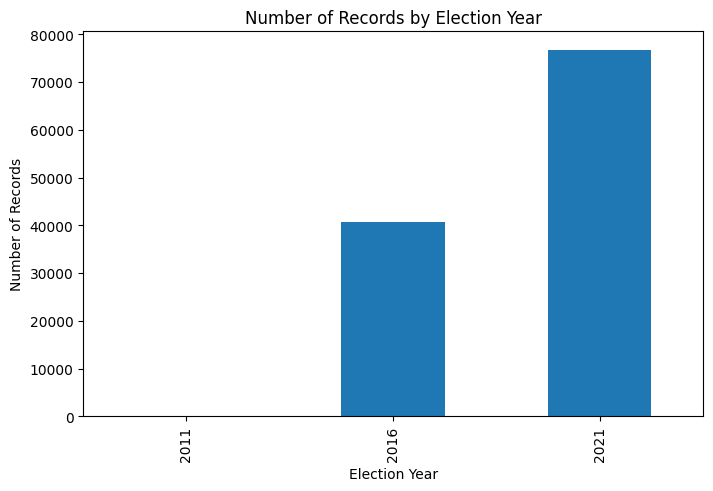

In [112]:
ethekwini_ts['election_year'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Number of Records by Election Year')
plt.xlabel('Election Year')
plt.ylabel('Number of Records')
plt.show()

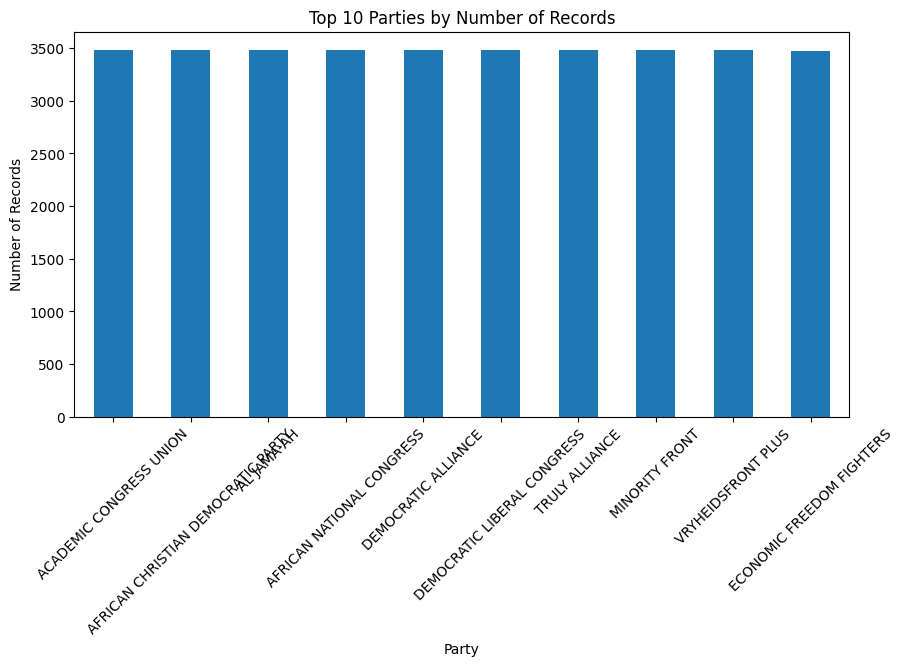

In [113]:
top_parties = ethekwini_ts['partyname'].value_counts().head(10)

top_parties.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top 10 Parties by Number of Records')
plt.xlabel('Party')
plt.ylabel('Number of Records')
plt.xticks(rotation=45)
plt.show()

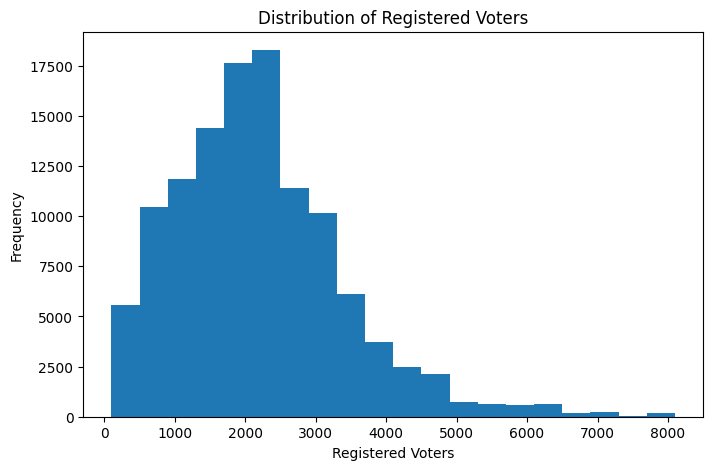

In [114]:
ethekwini_ts['registeredvoters'].plot(
    kind='hist',
    bins=20,
    figsize=(8,5)
)

plt.title('Distribution of Registered Voters')
plt.xlabel('Registered Voters')
plt.ylabel('Frequency')
plt.show()

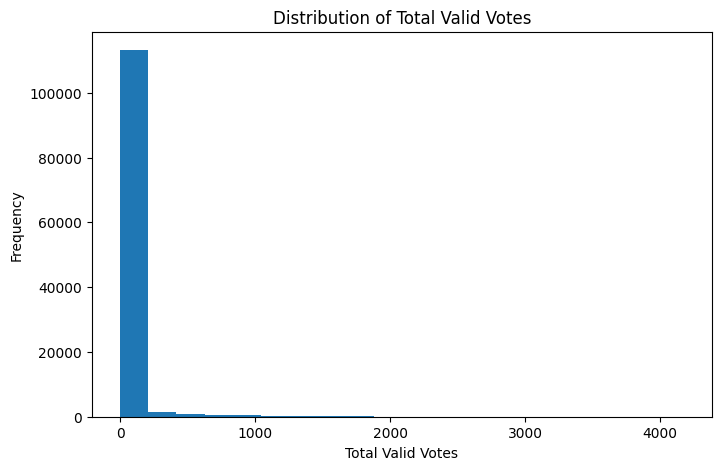

In [115]:
ethekwini_ts['totalvalidvotes'].plot(
    kind='hist',
    bins=20,
    figsize=(8,5)
)

plt.title('Distribution of Total Valid Votes')
plt.xlabel('Total Valid Votes')
plt.ylabel('Frequency')
plt.show()

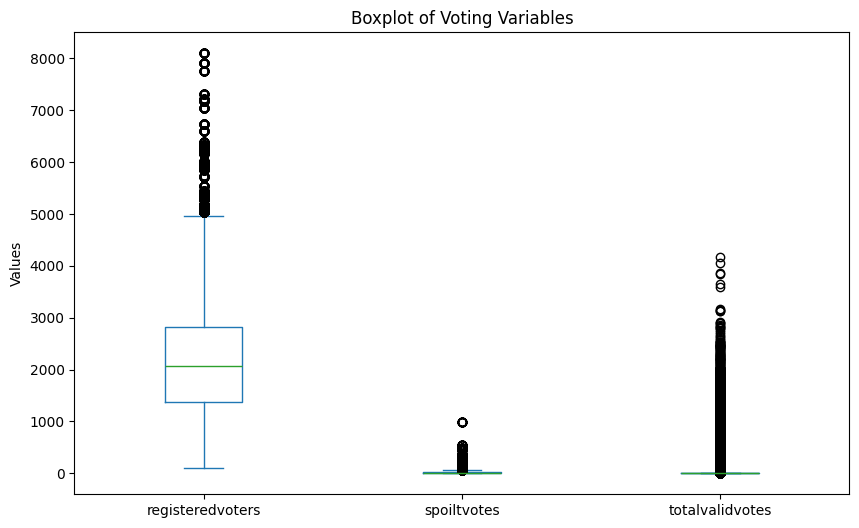

In [116]:
ethekwini_ts[
    ['registeredvoters', 'spoiltvotes', 'totalvalidvotes']
].plot(
    kind='box',
    figsize=(10,6)
)

plt.title('Boxplot of Voting Variables')
plt.ylabel('Values')
plt.show()

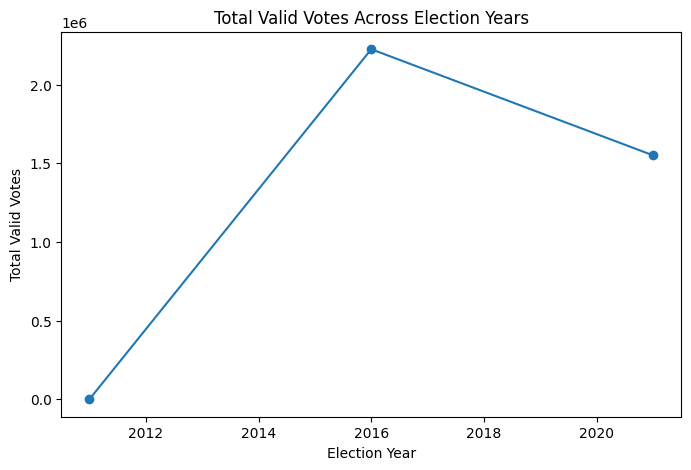

In [117]:
ethekwini_ts.groupby('election_year')['totalvalidvotes'].sum().plot(
    kind='line',
    marker='o',
    figsize=(8,5)
)

plt.title('Total Valid Votes Across Election Years')
plt.xlabel('Election Year')
plt.ylabel('Total Valid Votes')
plt.show()

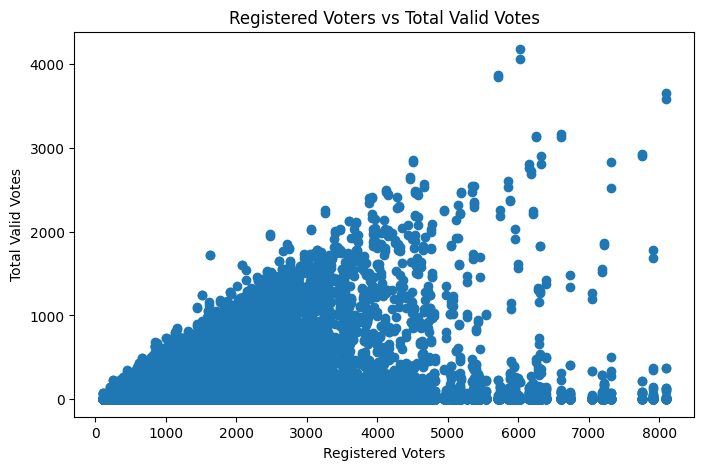

In [118]:
plt.figure(figsize=(8,5))

plt.scatter(
    ethekwini_ts['registeredvoters'],
    ethekwini_ts['totalvalidvotes']
)

plt.title('Registered Voters vs Total Valid Votes')
plt.xlabel('Registered Voters')
plt.ylabel('Total Valid Votes')
plt.show()

In [119]:
numeric_columns = ethekwini_ts.select_dtypes(include=np.number)

print(numeric_columns.corr())

                  votingdistrict  registeredvoters  spoiltvotes  \
votingdistrict          1.000000         -0.383401    -0.030569   
registeredvoters       -0.383401          1.000000     0.239700   
spoiltvotes            -0.030569          0.239700     1.000000   
totalvalidvotes        -0.037304          0.098434     0.034635   
election_year           0.001938         -0.013745    -0.148627   

                  totalvalidvotes  election_year  
votingdistrict          -0.037304       0.001938  
registeredvoters         0.098434      -0.013745  
spoiltvotes              0.034635      -0.148627  
totalvalidvotes          1.000000      -0.102115  
election_year           -0.102115       1.000000  


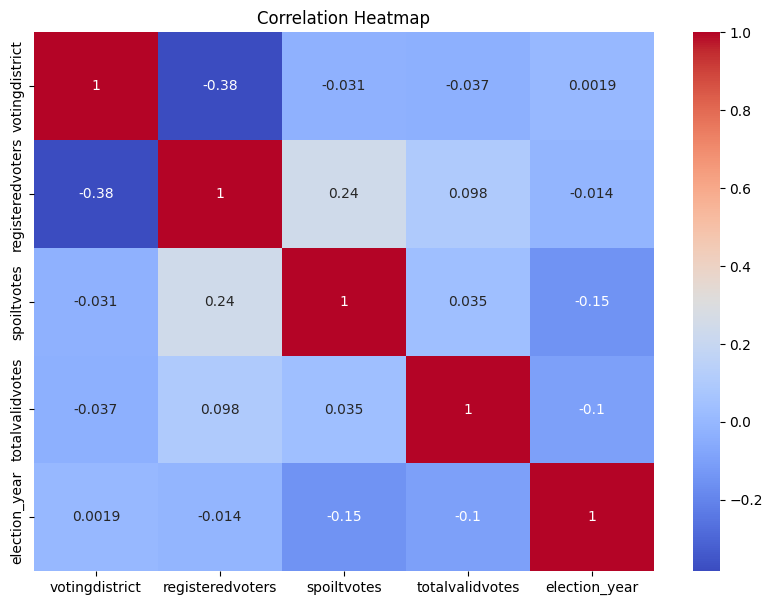

In [120]:
plt.figure(figsize=(10,7))

sns.heatmap(
    numeric_columns.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

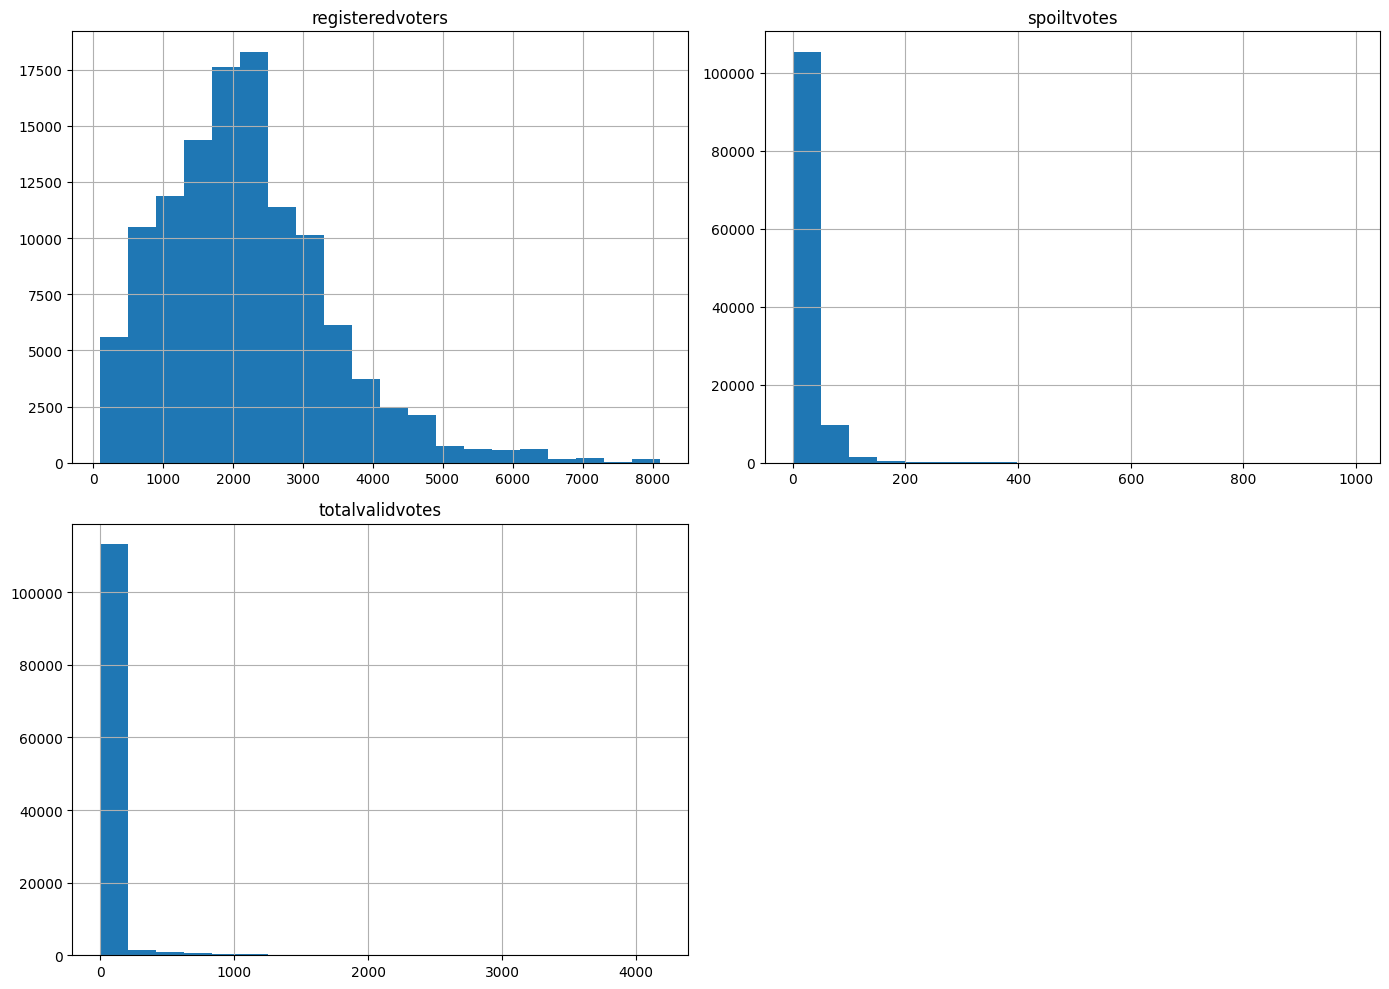

In [121]:
important_features = [
    "registeredvoters",
    "spoiltvotes",
    "totalvalidvotes"
]

ethekwini_ts[important_features].hist(
    figsize=(14, 10),
    bins=20
)

plt.tight_layout()
plt.show()

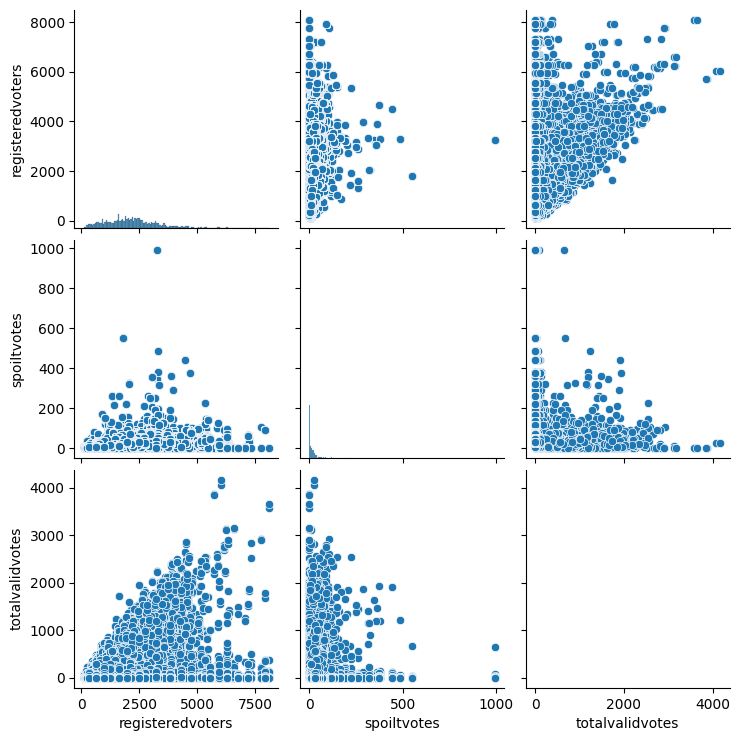

In [124]:
multivariate_features = [
    "registeredvoters",
    "spoiltvotes",
    "totalvalidvotes"
]

sns.pairplot(
    ethekwini_ts[multivariate_features]
)

plt.show()

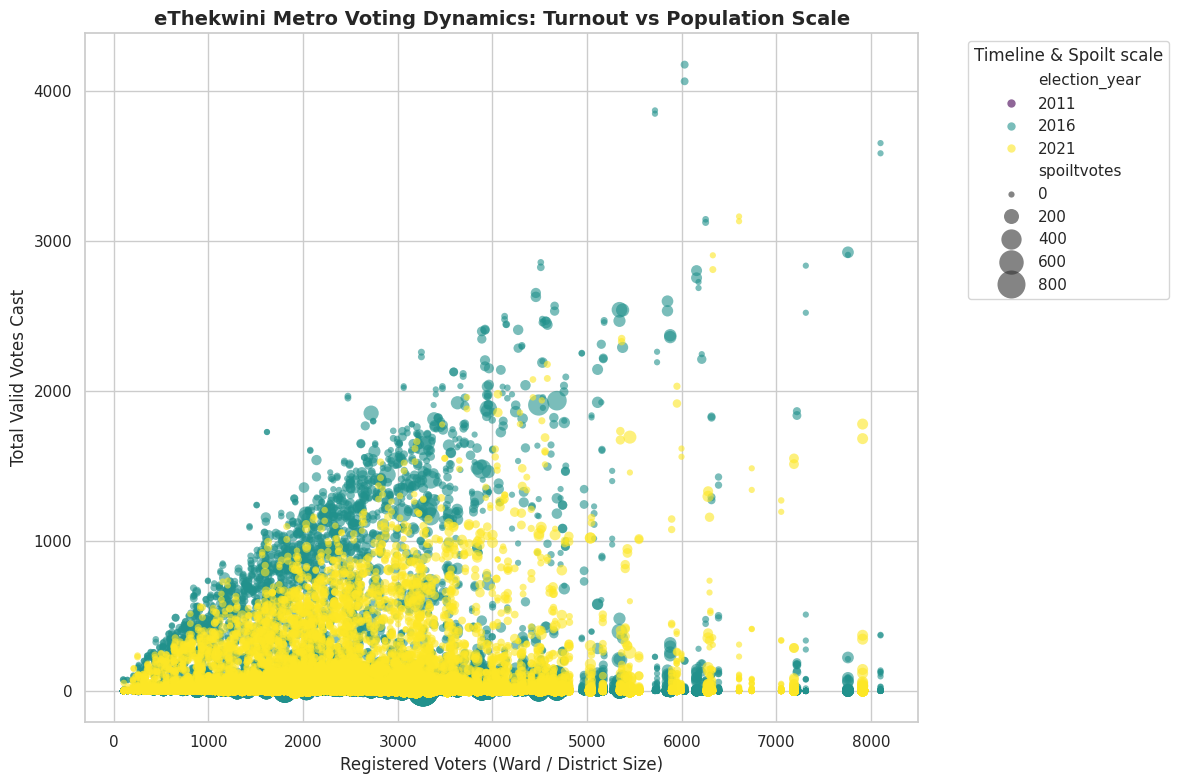

In [125]:
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

bubble_plot = sns.scatterplot(
    data=ethekwini_ts,
    x="registeredvoters",
    y="totalvalidvotes",
    size="spoiltvotes",
    hue="election_year",
    palette="viridis",
    sizes=(20, 500),
    alpha=0.6,
    edgecolor="none"
)

plt.title("eThekwini Metro Voting Dynamics: Turnout vs Population Scale", fontsize=14, weight='bold')
plt.xlabel("Registered Voters (Ward / District Size)", fontsize=12)
plt.ylabel("Total Valid Votes Cast", fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Timeline & Spoilt scale")

plt.tight_layout()
plt.show()

##6. Feature Engineering

In [126]:
from sklearn.preprocessing import StandardScaler

columns_to_drop = ['ÿþp'] + [f'unnamed:_{i}' for i in range(1, 11)]
ethekwini_ts.drop(columns=columns_to_drop, errors='ignore', inplace=True)

In [127]:
# Rename the broken province header
ethekwini_ts.rename(columns={'ï»¿province': 'province'}, inplace=True)

In [128]:
pr_ballots = ethekwini_ts[ethekwini_ts['ballottype'] == 'PR'].copy()

In [129]:
#LONGITUDINAL MATRIX RESTRUCTURING
features_df = pr_ballots.pivot_table(
    index=['election_year', 'ward'],
    columns='partyname',
    values='totalvalidvotes',
    aggfunc='sum'
).fillna(0)

In [130]:
#Feature creation
features_df['total_votes_cast'] = features_df.sum(axis=1)

In [131]:
#Derivation of a target atribute
target_party = 'AFRICAN NATIONAL CONGRESS'
features_df['target_party_share'] = (features_df[target_party] / features_df['total_votes_cast']) * 100

In [132]:
features_df['voter_density_tier'] = pd.cut(
    features_df['total_votes_cast'],
    bins=[0, 5000, 15000, 100000],
    labels=['Low Density', 'Medium Density', 'High Density']
)

In [133]:
#One hot encoding
features_df = pd.get_dummies(features_df, columns=['voter_density_tier'], prefix='tier', drop_first=True)

In [134]:
#Feature Scaling
scaler = StandardScaler()
features_df[['scaled_total_votes']] = scaler.fit_transform(features_df[['total_votes_cast']])

In [135]:
print("✅ Feature Engineering Complete. New Model Matrix:")
display(features_df[['total_votes_cast', 'target_party_share', 'scaled_total_votes']].head())


✅ Feature Engineering Complete. New Model Matrix:


total_votes_cast  target_party_share  \
election_year ward                                                  
2016          Ward 59500001           12156.0           92.571570   
              Ward 59500002           10084.0           88.724712   
              Ward 59500003            9464.0           80.388842   
              Ward 59500004            8029.0           76.535060   
              Ward 59500005            9274.0           90.101359   

                             scaled_total_votes  
election_year ward                               
2016          Ward 59500001            1.685102  
              Ward 59500002            0.729156  
              Ward 59500003            0.443110  
              Ward 59500004           -0.218948  
              Ward 59500005            0.355451

My target attribute is target_party_share.

This engineered attribute represents the percentage share of total valid votes won by the target political party (in this case, the African National Congress) within a specific ward during a specific election year

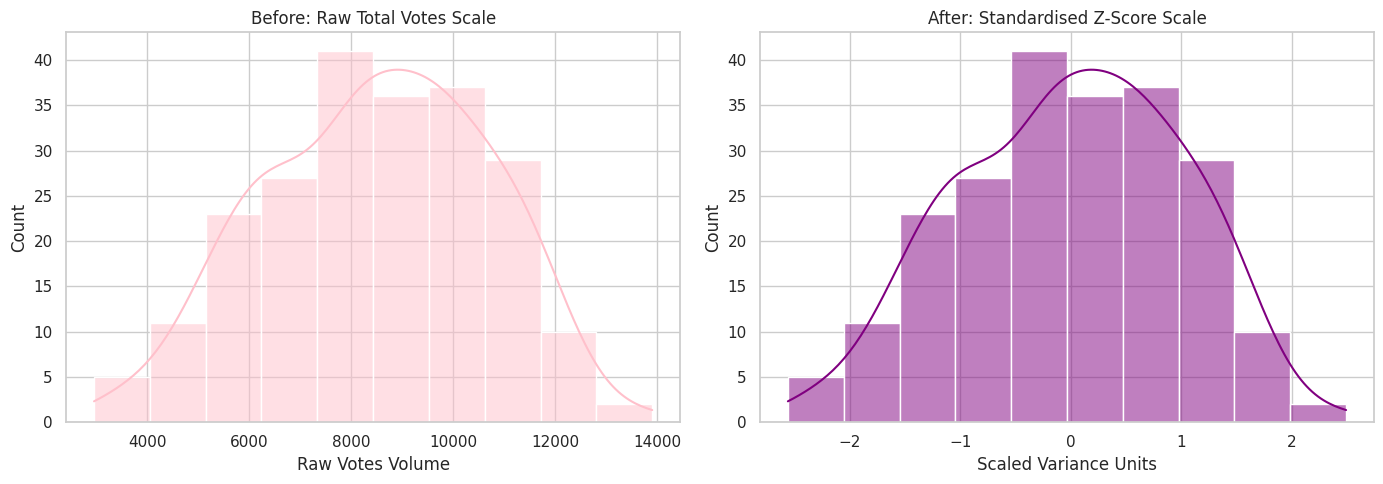

In [137]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: The original raw skewed counts
sns.histplot(features_df['total_votes_cast'], kde=True, ax=axes[0], color='pink')
axes[0].set_title('Before: Raw Total Votes Scale')
axes[0].set_xlabel('Raw Votes Volume')

# Plot 2: The standardized scaled distribution (Mean=0, Std=1)
sns.histplot(features_df['scaled_total_votes'], kde=True, ax=axes[1], color='purple')
axes[1].set_title('After: Standardised Z-Score Scale')
axes[1].set_xlabel('Scaled Variance Units')

plt.tight_layout()
plt.show()

##7. Machine Learning Model

In [152]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Filter out only Proportional Representation (PR) ballots
pr_ballots = ethekwini_ts[ethekwini_ts['ballottype'] == 'PR'].copy()

# 2. Pivot the data but instantly flatten the index layers
pivot_matrix = pr_ballots.pivot_table(
    index=['election_year', 'ward'],
    columns='partyname',
    values='totalvalidvotes',
    aggfunc='sum'
).fillna(0).reset_index()

# 3. Calculate total vote cast and isolate your y target array
pivot_matrix['total_votes_cast'] = pivot_matrix.drop(columns=['election_year', 'ward']).sum(axis=1)
y_target = (pivot_matrix['AFRICAN NATIONAL CONGRESS'] / pivot_matrix['total_votes_cast']) * 100


X_features = pivot_matrix.drop(columns=['election_year', 'ward', 'AFRICAN NATIONAL CONGRESS', 'total_votes_cast'], errors='ignore')

# 5. Perform the timeline split safely using identical flat row slices
train_mask = pivot_matrix['election_year'] < 2021
test_mask = pivot_matrix['election_year'] == 2021

X_train, y_train = X_features[train_mask], y_target[train_mask]
X_test, y_test = X_features[test_mask], y_target[test_mask]


boosting_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
boosting_model.fit(X_train, y_train)

# Calculate testing predictions
predictions = boosting_model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("🌲 Multi-Party Tree Ensemble Complete with Zero Errors!")
print(f"Total numeric features used for splitting: {X_train.shape}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Prediction Accuracy Score: {r2:.2f}")


🌲 Multi-Party Tree Ensemble Complete with Zero Errors!
Total numeric features used for splitting: (110, 55)
Mean Squared Error (MSE): 203.24
R² Prediction Accuracy Score: 0.54


## Forecasting

In [156]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from prophet import Prophet


# Filter exclusively for Proportional Representation (PR) ballots
pr_ballots = ethekwini_ts[ethekwini_ts['ballottype'] == 'PR'].copy()

# Collapse separate rows into a clean, uniform timeline total for the whole Metro
yearly_totals = pr_ballots.groupby(['election_year']).agg({
    'totalvalidvotes': 'sum'
}).reset_index()

# Extract the specific historical target (ANC) total vote volumes per cycle
anc_totals = pr_ballots[pr_ballots['partyname'] == 'AFRICAN NATIONAL CONGRESS'].groupby(['election_year']).agg({
    'totalvalidvotes': 'sum'
}).reset_index().rename(columns={'totalvalidvotes': 'anc_votes'})

# Merge to create a single clean timeline dataframe
merged_timeline = pd.merge(yearly_totals, alt_totals := anc_totals, on='election_year')

# Engineer your target attribute fraction (%)
merged_timeline['target_party_share'] = (merged_timeline['anc_votes'] / merged_timeline['totalvalidvotes']) * 100

prophet_df = pd.DataFrame()
# Convert integer years to uniform timestamp markers
prophet_df['ds'] = pd.to_datetime(merged_timeline['election_year'].astype(str) + '-11-01')
prophet_df['y'] = merged_timeline['target_party_share']

# Enforce clean temporal sort order to prevent leakage (Slide 11)
prophet_df = prophet_df.sort_values(by='ds').reset_index(drop=True)

# Split: Train on historical data (2011, 2016), Test/Validate on the future (2021)
train_df = prophet_df[prophet_df['ds'].dt.year < 2021].copy()
test_df = prophet_df[prophet_df['ds'].dt.year == 2021].copy()

# Initialize Prophet without high-frequency seasonals to match the 5-year sparse scale
model_prophet = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
model_prophet.fit(train_df)

# Construct a dataframe holding the future target timestamp (2021)
future_horizon = model_prophet.make_future_dataframe(periods=1, freq='5Y')

# Generate the timeline forecast projection matrix
forecast = model_prophet.predict(future_horizon)

# Isolate the model's predicted point for the 2021 cycle window
predicted_share = forecast.iloc[-1]['yhat']

actual_y = test_df['y'].values
pred_y = np.full(shape=len(actual_y), fill_value=predicted_share)

# Calculate the error metrics requested by Lesson 25
mae = mean_absolute_error(actual_y, pred_y)
mse = mean_squared_error(actual_y, pred_y)
rmse = np.sqrt(mse)

print("📈 Prophet Time-Series Forecasting Pipeline Complete!")
print(f"Projected ANC Vote Share Estimate for 2021: {predicted_share:.2f}%")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")


ValueError: Dataframe has less than 2 non-NaN rows.